## Parse Data

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def list_to_plate(lst: pd.Series) -> pd.DataFrame:
    new_index = pd.MultiIndex.from_tuples([(i[0], int(i[1:])) for i in lst.index])
    plate =  pd.Series(lst.values, index=new_index).unstack()
    return plate

def plate_to_list(plate: pd.DataFrame) -> pd.Series:
    s = plate.stack()
    s.index = [f'{row}{col}' for row, col in s.index]
    return s

def set_plate_axes(df: pd.DataFrame) -> pd.DataFrame:
    """ Given a dataframe representing a multiwell plate, set axes to be proper plate axes. """

    df.columns = range(1, len(df.columns)+1)
    df.index = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P'][:len(df.index)]
    return df

def bars(df, **kwargs):
    ax = sns.barplot(data=df,alpha=0.8, **kwargs)
    ax = sns.stripplot(data=df, ax=ax, size=6, dodge=True, legend=False,  edgecolor='black', linewidth=1, **kwargs)
    if 'hue' in kwargs.keys():
      plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    return ax


In [4]:
import pandas as pd

from pathlib import Path
DRIVE_FOLDER = Path('')



cts_day1 = pd.read_csv(DRIVE_FOLDER / '20241007_iDEC_PANCE_day 1.txt', sep='\t', header=1)[['Pos', 'Cp']]
cts_day1 = list_to_plate(cts_day1.set_index('Pos').Cp)

cts_day2 = pd.read_csv(DRIVE_FOLDER / '20241008_idec_pance_day2.txt', sep='\t', header=1)[['Pos', 'Cp']]
cts_day2 = list_to_plate(cts_day2.set_index('Pos').Cp)


cts_day3 = pd.read_csv(DRIVE_FOLDER / '20241005_iDEC_day3.txt', sep='\t', header=1)[['Pos', 'Cp']]
cts_day3 = list_to_plate(cts_day3.set_index('Pos').Cp)



cts_day4 = pd.read_csv(DRIVE_FOLDER / '20241008_iDEC_PANCE_day4.txt', sep='\t', header=1)[['Pos', 'Cp']]
cts_day4 = list_to_plate(cts_day4.set_index('Pos').Cp)





layout_plate1 = pd.read_excel(DRIVE_FOLDER / 'Plate Layout.xlsx', header=None)


In [5]:
cts_day2

,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
A,28.80,30.13,26.87,28.26,27.60,31.03,28.65,29.52,18.87,18.77,...,30.00,30.35,30.46,30.05,30.50,31.67,15.30,15.17,15.18,15.22
B,26.45,27.68,27.83,27.08,32.72,32.96,33.00,32.72,22.27,22.59,...,28.66,29.60,32.64,33.12,32.57,33.01,17.48,17.71,17.14,17.41
C,27.26,29.90,28.01,29.85,31.03,30.92,30.75,30.95,25.54,24.46,...,30.08,30.84,33.45,33.05,31.62,31.07,18.87,18.82,19.76,19.87
D,27.43,29.52,27.84,29.54,26.87,28.59,31.87,31.64,28.22,29.35,...,30.49,31.24,32.34,31.88,32.32,32.46,30.44,29.97,29.92,28.52
E,29.69,29.87,30.18,28.21,28.64,30.73,30.43,29.18,32.87,33.06,...,30.80,31.23,29.14,29.43,27.26,27.58,28.09,27.56,33.28,33.30
F,30.33,30.23,29.34,28.75,25.59,26.12,27.61,27.05,29.75,28.59,...,30.74,31.33,24.02,24.09,26.20,26.23,31.78,29.65,31.78,31.46
G,30.67,31.23,31.70,31.69,33.32,32.93,33.17,32.70,26.22,25.14,...,32.32,32.62,33.25,32.87,32.78,32.24,20.92,20.89,20.72,21.59
H,24.78,24.24,25.45,25.32,22.50,22.62,21.97,21.75,26.62,25.74,...,19.03,18.95,17.43,17.24,19.53,19.49,20.74,20.90,21.59,21.31
I,33.89,34.27,33.03,34.49,35.19,35.03,35.09,34.14,33.80,35.04,...,33.91,34.13,35.41,33.93,34.13,34.82,34.31,35.10,34.05,34.56
J,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:

cts1 = plate_to_list(set_plate_axes(cts_day1.iloc[:8, ::2])).reset_index().rename(columns={0: 'ct', 'index': 'well'})
cts1['plate'] = 'plate1'
cts1['day'] = 1
cts2 = plate_to_list(set_plate_axes(cts_day1.iloc[:8, 1::2])).reset_index().rename(columns={0: 'ct', 'index': 'well'})
cts2['plate'] = 'plate2'
cts2['day'] = 1


cts3 = plate_to_list(set_plate_axes(cts_day2.iloc[:8, ::2])).reset_index().rename(columns={0: 'ct', 'index': 'well'})
cts3['plate'] = 'plate1'
cts3['day'] = 2
cts4 = plate_to_list(set_plate_axes(cts_day2.iloc[:8, 1::2])).reset_index().rename(columns={0: 'ct', 'index': 'well'})
cts4['plate'] = 'plate2'
cts4['day'] = 2


cts5 = plate_to_list(set_plate_axes(cts_day3.iloc[:8, ::2])).reset_index().rename(columns={0: 'ct', 'index': 'well'})
cts5['plate'] = 'plate1'
cts5['day'] = 3
cts6 = plate_to_list(set_plate_axes(cts_day3.iloc[:8, 1::2])).reset_index().rename(columns={0: 'ct', 'index': 'well'})
cts6['plate'] = 'plate2'
cts6['day'] = 3


cts7 = plate_to_list(set_plate_axes(cts_day4.iloc[:8, ::2])).reset_index().rename(columns={0: 'ct', 'index': 'well'})
cts7['plate'] = 'plate1'
cts7['day'] = 4
cts8 = plate_to_list(set_plate_axes(cts_day4.iloc[:8, 1::2])).reset_index().rename(columns={0: 'ct', 'index': 'well'})
cts8['plate'] = 'plate2'
cts8['day'] = 4





cts_all = pd.concat([cts1, #cts2, # day 1
                     cts3, #cts4, # day 2
                     cts5, #cts6, # day 3
                     cts7, #cts8, # day 4
                     ])


In [7]:
list_to_plate(cts3.set_index('well').ct)

,1,2,3,4,5,6,7,8,9,10,11,12
A,28.80,26.87,27.60,28.65,18.87,18.95,28.96,30.00,30.46,30.50,15.30,15.18
B,26.45,27.83,32.72,33.00,22.27,22.63,29.62,28.66,32.64,32.57,17.48,17.14
C,27.26,28.01,31.03,30.75,25.54,23.30,30.84,30.08,33.45,31.62,18.87,19.76
D,27.43,27.84,26.87,31.87,28.22,29.06,31.58,30.49,32.34,32.32,30.44,29.92
E,29.69,30.18,28.64,30.43,32.87,26.61,28.80,30.80,29.14,27.26,28.09,33.28
F,30.33,29.34,25.59,27.61,29.75,30.25,29.78,30.74,24.02,26.20,31.78,31.78
G,30.67,31.70,33.32,33.17,26.22,25.54,33.18,32.32,33.25,32.78,20.92,20.72
H,24.78,25.45,22.50,21.97,26.62,26.99,18.83,19.03,17.43,19.53,20.74,21.59


In [8]:
cts_all.day.unique()

array([1, 2, 3, 4])

In [9]:
def parse_plate(df, num_cols):
  pass

def parse_layout(layout: pd.DataFrame):
  idx = 0
  plates = []
  while idx < len(layout.index)-9:
    if layout.iloc[idx, 0] is not None:
      plate = set_plate_axes(layout.iloc[idx+2:idx+2+8, 1:1+12])
      print(plate)
      plate = plate_to_list(plate)
      plate.name = layout.iloc[idx,  0]
      plates.append(plate)
      idx += 11
    else:
      idx += 1
  return pd.concat(plates, axis=1)

meta_plate1 = parse_layout(layout_plate1).reset_index().rename(columns={'index': 'well'})
meta_plate1['plate'] = 'plate1'


meta = pd.concat([meta_plate1])


           1           2           3           4           5           6   \
A  1084-44-00  1084-44-00  1084-44-00  1084-44-00  1029-08-00  1029-08-00   
B  1117-44-00  1117-44-00  1117-44-00  1117-44-00  1033-09-00  1033-09-00   
C  1120-44-00  1120-44-00  1120-44-00  1120-44-00  1035-08-00  1035-08-00   
D  1124-44-00  1124-44-00  1124-44-00  1124-44-00  1035-08-00  1035-08-00   
E  1131-44-00  1131-44-00  1131-44-00  1131-44-00          LB          LB   
F  1151-44-00  1151-44-00  1151-44-00  1151-44-00       S2060       S2060   
G  1084-69-00  1084-69-00  1084-69-00  1084-69-00  1131-69-00  1131-69-00   
H  1117-69-00  1117-69-00  1117-69-00  1117-69-00  1151-69-00  1151-69-00   

           7           8           9           10          11          12  
A  1084-44-00  1084-44-00  1084-44-00  1084-44-00  1029-08-00  1029-08-00  
B  1117-44-00  1117-44-00  1117-44-00  1117-44-00  1033-09-00  1033-09-00  
C  1120-44-00  1120-44-00  1120-44-00  1120-44-00  1035-08-00  1035-08-00  
D 

In [10]:
meta['sample'] = 'C-' + meta['Promoter C-term'] + '-' + meta['Linker'] + '-' + meta['Substrate'] + ' + N-' + meta['Promoter N-term']
meta

,well,Strain 1,Replicate,Vanillic acid concentration [µM],Linker,Substrate,Promoter C-term,Promoter N-term,Phage,plate,sample
0,A1,1084-44-00,A,1,L4,EGLN3,pVan,pVan,SIAH1,plate1,C-pVan-L4-EGLN3 + N-pVan
1,A2,1084-44-00,B,1,L4,EGLN3,pVan,pVan,SIAH1,plate1,C-pVan-L4-EGLN3 + N-pVan
2,A3,1084-44-00,A,10,L4,EGLN3,pVan,pVan,SIAH1,plate1,C-pVan-L4-EGLN3 + N-pVan
3,A4,1084-44-00,B,10,L4,EGLN3,pVan,pVan,SIAH1,plate1,C-pVan-L4-EGLN3 + N-pVan
4,A5,1029-08-00,A,0,L2,EGLN3,p70,p70,SIAH1,plate1,C-p70-L2-EGLN3 + N-p70
...,...,...,...,...,...,...,...,...,...,...,...
91,H8,1117-69-00,B,1,L4,ASYN,pVan,p70,TadA,plate1,C-pVan-L4-ASYN + N-p70
92,H9,1117-69-00,A,10,L4,ASYN,pVan,p70,TadA,plate1,C-pVan-L4-ASYN + N-p70
93,H10,1117-69-00,B,10,L4,ASYN,pVan,p70,TadA,plate1,C-pVan-L4-ASYN + N-p70
94,H11,1151-69-00,A,0,L4,EGLN3,psp,p70,TadA,plate1,C-psp-L4-EGLN3 + N-p70


In [11]:
df = pd.merge(cts_all, meta, on=['well', 'plate'], how='inner')
df

,well,ct,plate,day,Strain 1,Replicate,Vanillic acid concentration [µM],Linker,Substrate,Promoter C-term,Promoter N-term,Phage,sample
0,A1,25.59,plate1,1,1084-44-00,A,1,L4,EGLN3,pVan,pVan,SIAH1,C-pVan-L4-EGLN3 + N-pVan
1,A2,25.90,plate1,1,1084-44-00,B,1,L4,EGLN3,pVan,pVan,SIAH1,C-pVan-L4-EGLN3 + N-pVan
2,A3,27.15,plate1,1,1084-44-00,A,10,L4,EGLN3,pVan,pVan,SIAH1,C-pVan-L4-EGLN3 + N-pVan
3,A4,28.63,plate1,1,1084-44-00,B,10,L4,EGLN3,pVan,pVan,SIAH1,C-pVan-L4-EGLN3 + N-pVan
4,A5,20.80,plate1,1,1029-08-00,A,0,L2,EGLN3,p70,p70,SIAH1,C-p70-L2-EGLN3 + N-p70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,H8,20.07,plate1,4,1117-69-00,B,1,L4,ASYN,pVan,p70,TadA,C-pVan-L4-ASYN + N-p70
380,H9,17.42,plate1,4,1117-69-00,A,10,L4,ASYN,pVan,p70,TadA,C-pVan-L4-ASYN + N-p70
381,H10,18.35,plate1,4,1117-69-00,B,10,L4,ASYN,pVan,p70,TadA,C-pVan-L4-ASYN + N-p70
382,H11,20.66,plate1,4,1151-69-00,A,0,L4,EGLN3,psp,p70,TadA,C-psp-L4-EGLN3 + N-p70


In [12]:
# tech_rep_std = df.groupby(['Strain 1', 'plate', 'day', 'Replicate', 'Vanillic acid concentration [µM]']).ct.std().reset_index().rename(columns={'ct': 'tech_rep_std'})
# df = pd.merge(df, tech_rep_std, on=['Strain 1', 'plate', 'day', 'Replicate', 'Vanillic acid concentration [µM]'])
# df

In [13]:
df['Strain 1'].unique()

array(['1084-44-00', '1029-08-00', '1117-44-00', '1033-09-00',
       '1120-44-00', '1035-08-00', '1124-44-00', '1131-44-00', 'LB',
       '1151-44-00', 'S2060', '1084-69-00', '1131-69-00', '1117-69-00',
       '1151-69-00'], dtype=object)

In [14]:
#df.loc[df.ct > 30, 'ct'] = 35
# df.loc[df.tech_rep_std > 2, 'ct'] = pd.NA


In [64]:
df[df.day == 3]

,well,ct,plate,day,Strain 1,Replicate,Vanillic acid concentration [µM],Linker,Substrate,Promoter C-term,Promoter N-term,Phage,sample
192,A1,32.13,plate1,3,1084-44-00,A,1,L4,EGLN3,pVan,pVan,SIAH1,C-pVan-L4-EGLN3 + N-pVan
193,A2,29.00,plate1,3,1084-44-00,B,1,L4,EGLN3,pVan,pVan,SIAH1,C-pVan-L4-EGLN3 + N-pVan
194,A3,31.47,plate1,3,1084-44-00,A,10,L4,EGLN3,pVan,pVan,SIAH1,C-pVan-L4-EGLN3 + N-pVan
195,A4,31.81,plate1,3,1084-44-00,B,10,L4,EGLN3,pVan,pVan,SIAH1,C-pVan-L4-EGLN3 + N-pVan
196,A5,20.36,plate1,3,1029-08-00,A,0,L2,EGLN3,p70,p70,SIAH1,C-p70-L2-EGLN3 + N-p70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,H8,16.57,plate1,3,1117-69-00,B,1,L4,ASYN,pVan,p70,TadA,C-pVan-L4-ASYN + N-p70
284,H9,14.58,plate1,3,1117-69-00,A,10,L4,ASYN,pVan,p70,TadA,C-pVan-L4-ASYN + N-p70
285,H10,15.94,plate1,3,1117-69-00,B,10,L4,ASYN,pVan,p70,TadA,C-pVan-L4-ASYN + N-p70
286,H11,18.08,plate1,3,1151-69-00,A,0,L4,EGLN3,psp,p70,TadA,C-psp-L4-EGLN3 + N-p70


## Results

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/1547004465.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


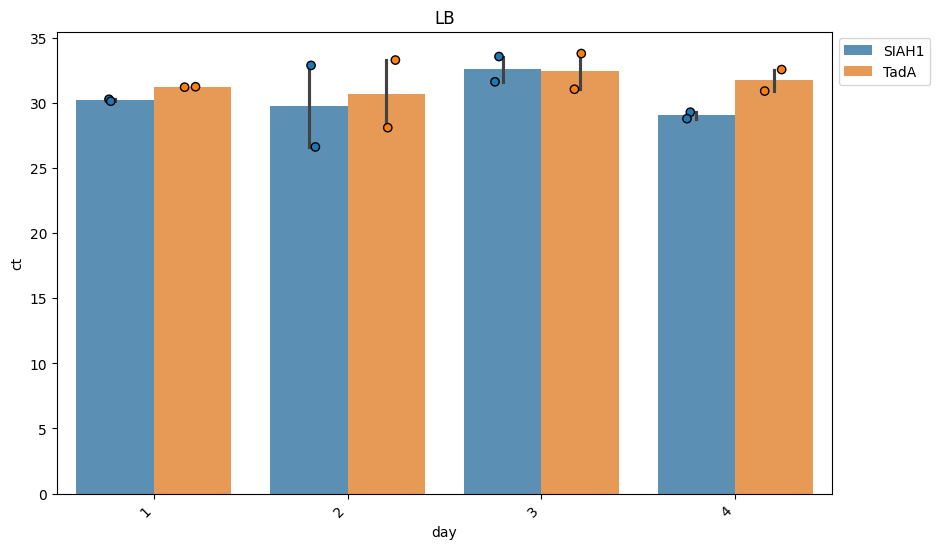

In [16]:
df_ctrl = df[df['Strain 1'].isin({'LB'})]

fig, ax = plt.subplots(figsize=(10, 6))
ax = bars(df_ctrl, x='day', y='ct', hue='Phage')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'LB')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/3901909462.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


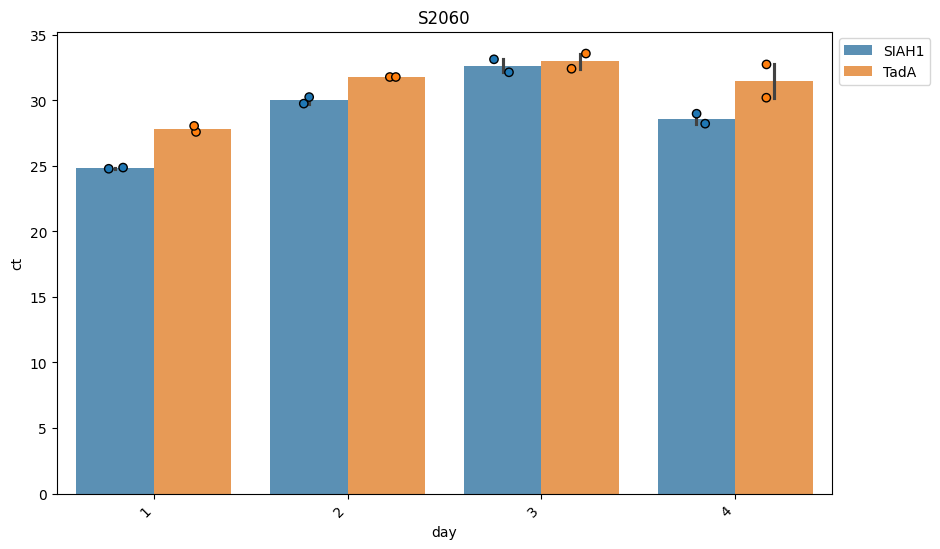

In [17]:
df_ctrl = df[df['Strain 1'].isin({'S2060'})]

fig, ax = plt.subplots(figsize=(10, 6))
ax = bars(df_ctrl, x='day', y='ct', hue='Phage')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'S2060')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/3259207561.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ctrl['Strain 1'] = df_ctrl['Strain 1'].map(lambda x: {'1117-69-00': 'with selection logic', 'S2060': 'w/o selection logic'}.get(x, x))


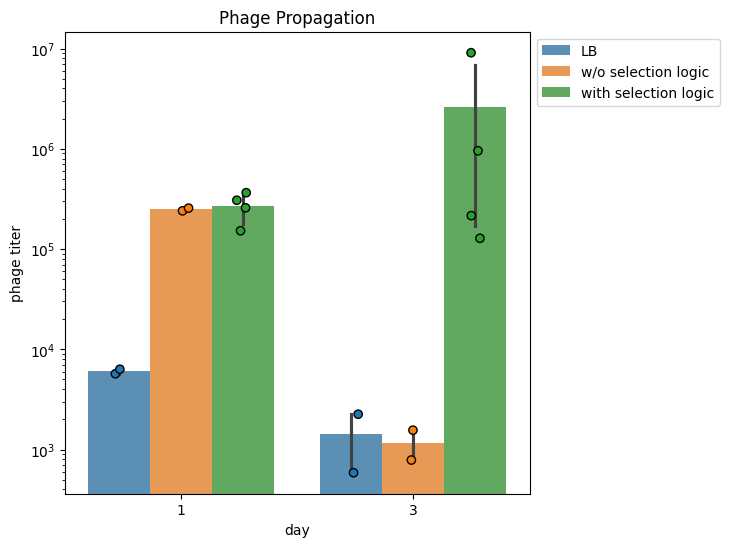

In [79]:
df_ctrl = df[df['Phage'].isin({'SIAH1'}) & df['Strain 1'].isin({'LB', 'S2060', '1117-69-00'}) & df.day.isin({1, 3})]
df_ctrl['Strain 1'] = df_ctrl['Strain 1'].map(lambda x: {'1117-69-00': 'with selection logic', 'S2060': 'w/o selection logic'}.get(x, x))
df_ctrl.loc[:, 'phage titer'] = 220000 * 2 ** (25 - df_ctrl.ct) 
fig, ax = plt.subplots(figsize=(6, 6))
ax = bars(df_ctrl, x='day', y='phage titer', hue='Strain 1')
ax.set_title(f'Phage Propagation')
ax.set_yscale('log')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/1394891375.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


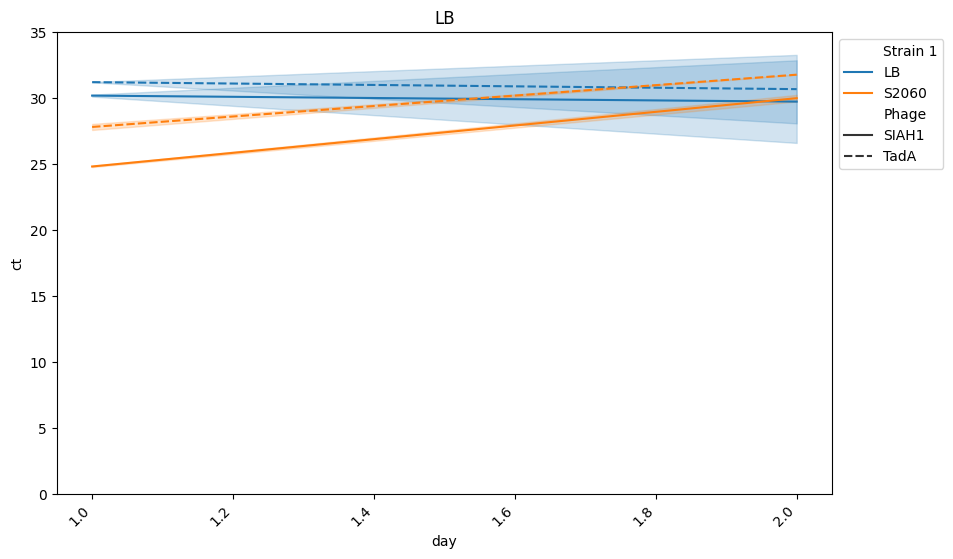

In [58]:
df_ctrl = df[df['Strain 1'].isin({'LB', 'S2060'}) & (df.day < 3)]

fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.lineplot(df_ctrl, x='day', y='ct', hue='Strain 1', style='Phage')
ax.set_ylim(0, 35)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'LB')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/1623934827.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


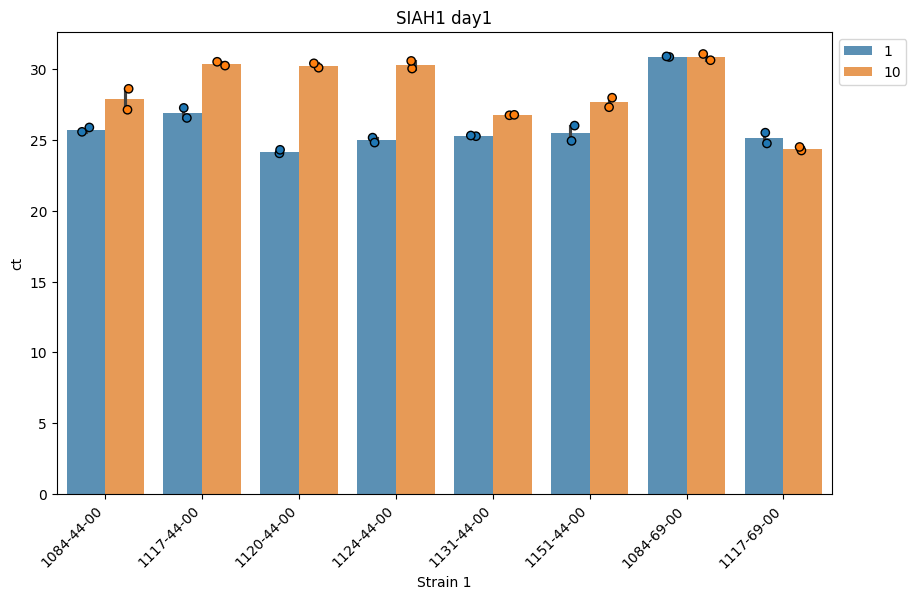

In [18]:
df_d1_siah1 = df[(df['Phage'] == 'SIAH1') & (df['day'] == 1) & (df['Vanillic acid concentration [µM]'] != 0)]

fig, ax = plt.subplots(figsize=(10, 6))
ax = bars(df_d1_siah1, y='ct', x='Strain 1', hue='Vanillic acid concentration [µM]', palette='tab10')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'SIAH1 day1')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/4172346576.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


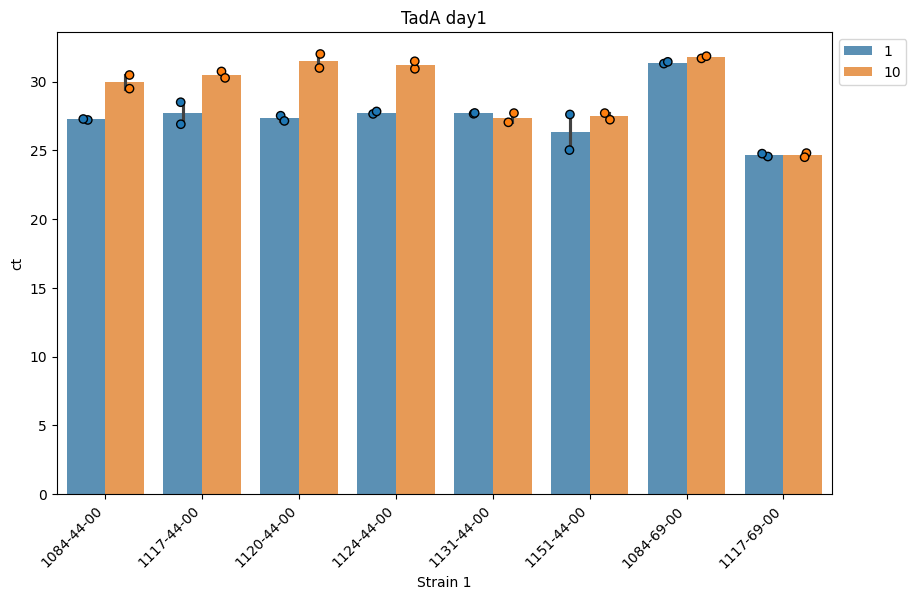

In [19]:
df_d1_tada = df[(df['Phage'] == 'TadA') & (df['day'] == 1) & (df['Vanillic acid concentration [µM]'] != 0)]

fig, ax = plt.subplots(figsize=(10, 6))
ax = bars(df_d1_tada, y='ct', x='Strain 1', hue='Vanillic acid concentration [µM]', palette='tab10')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'TadA day1')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/3215147139.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


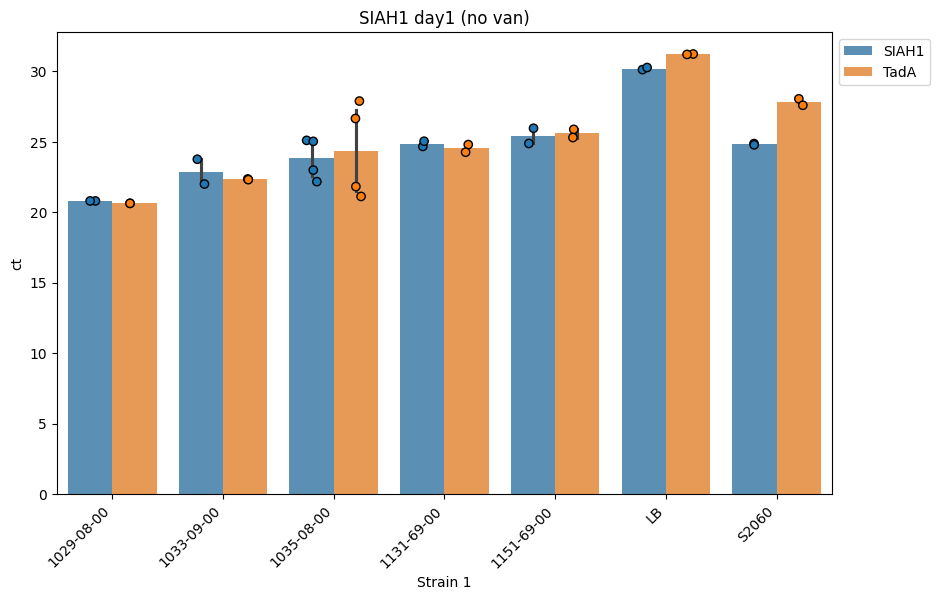

In [20]:
df_d1_novan= df[(df['day'] == 1) & (df['Vanillic acid concentration [µM]'] == 0)].sort_values('Strain 1')

fig, ax = plt.subplots(figsize=(10, 6))
ax = bars(df_d1_novan, y='ct', x='Strain 1', hue='Phage', palette='tab10')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'SIAH1 day1 (no van)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/1892543423.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


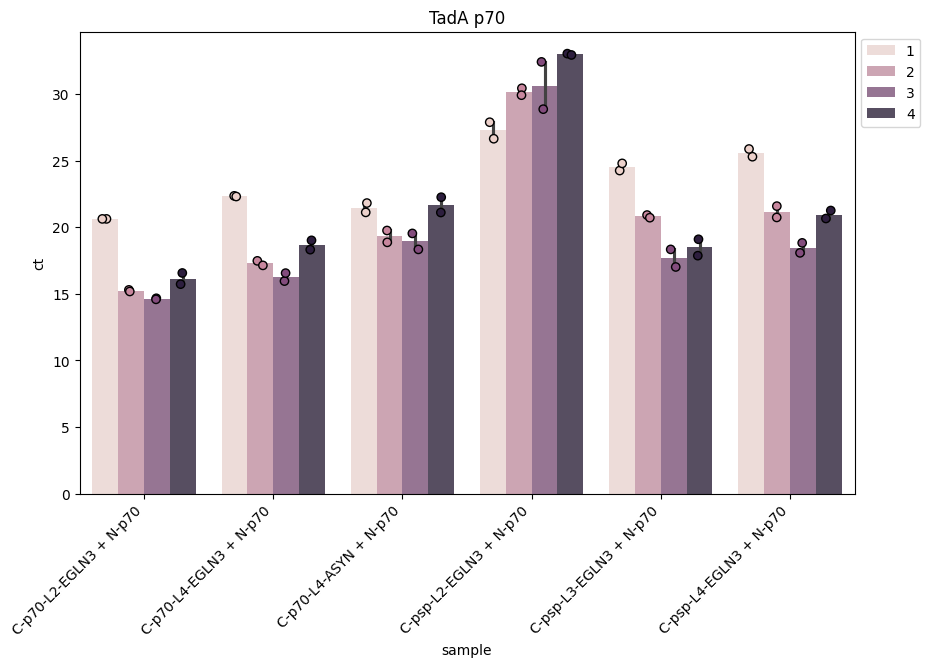

In [21]:
df_tada = df[(df['Phage'] == 'TadA') & ~df['Strain 1'].isin({'LB', 'S2060'})]

fig, ax = plt.subplots(figsize=(10, 6))
ax = bars(df_tada[df_tada['Vanillic acid concentration [µM]'] == 0], x='sample', y='ct', hue='day')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'TadA p70')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/3420911515.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


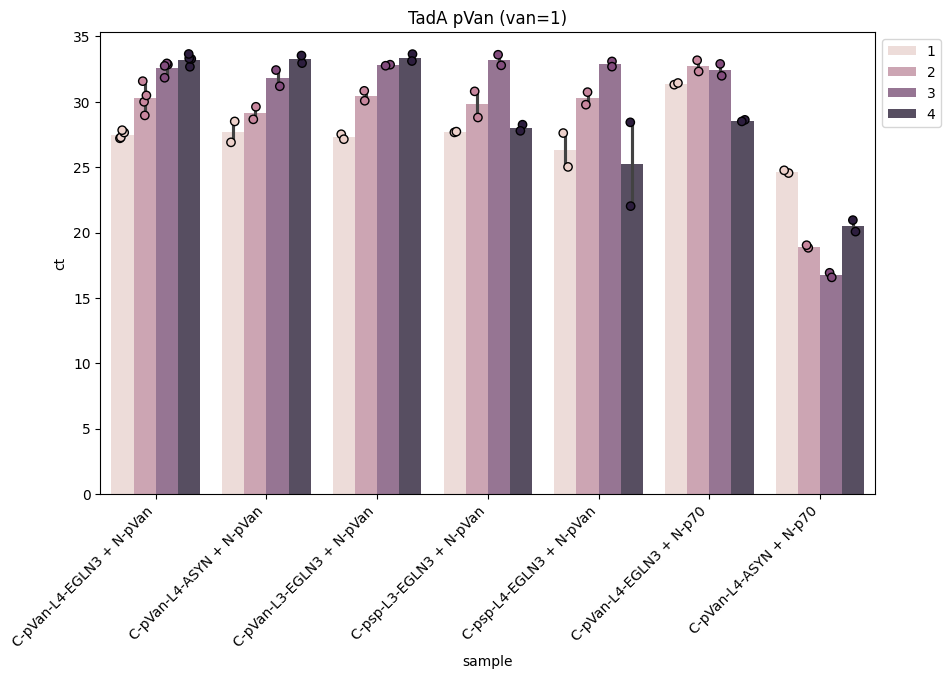

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = bars(df_tada[df_tada['Vanillic acid concentration [µM]'] == 1], x='sample', y='ct', hue='day')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'TadA pVan (van=1)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/1469286318.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


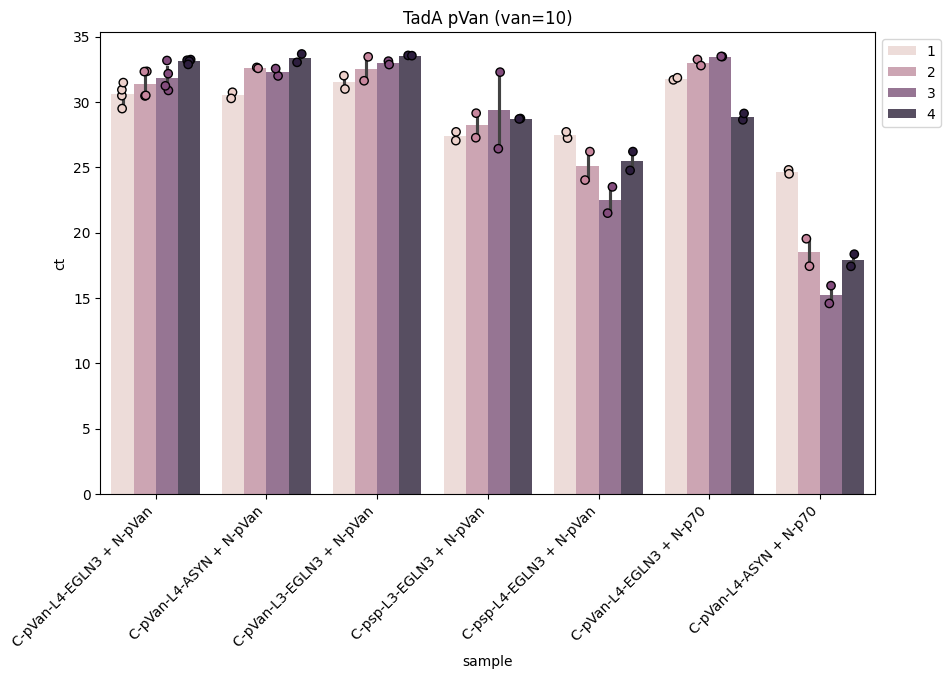

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = bars(df_tada[df_tada['Vanillic acid concentration [µM]'] == 10], x='sample', y='ct', hue='day')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'TadA pVan (van=10)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/3007816668.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


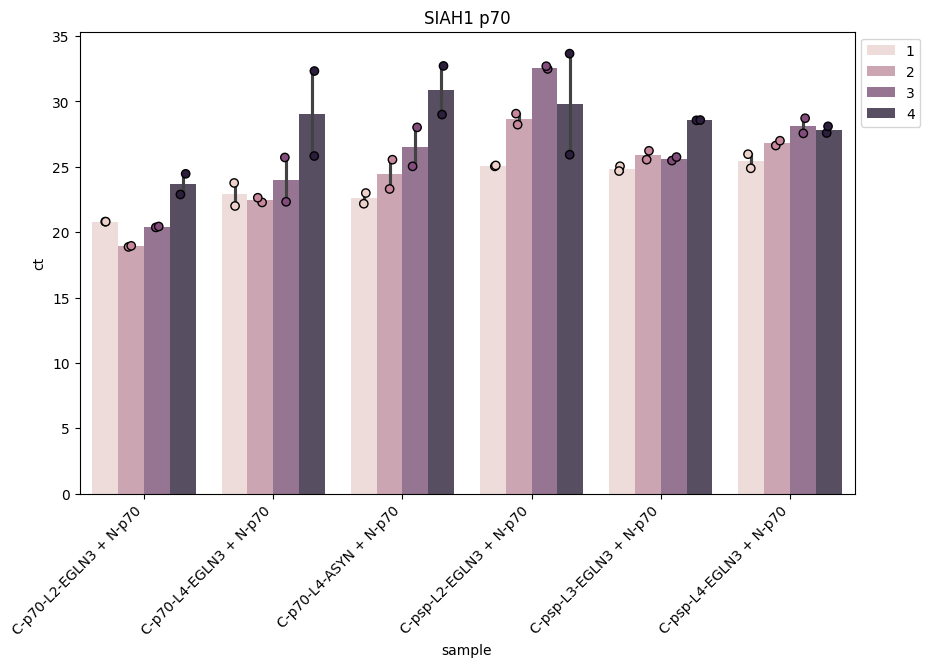

In [24]:
df_siah = df[(df['Phage'] == 'SIAH1') & ~df['Strain 1'].isin({'LB', 'S2060'})]

fig, ax = plt.subplots(figsize=(10, 6))
ax = bars(df_siah[df_siah['Vanillic acid concentration [µM]'] == 0], x='sample', y='ct', hue='day')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'SIAH1 p70')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/3257341545.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


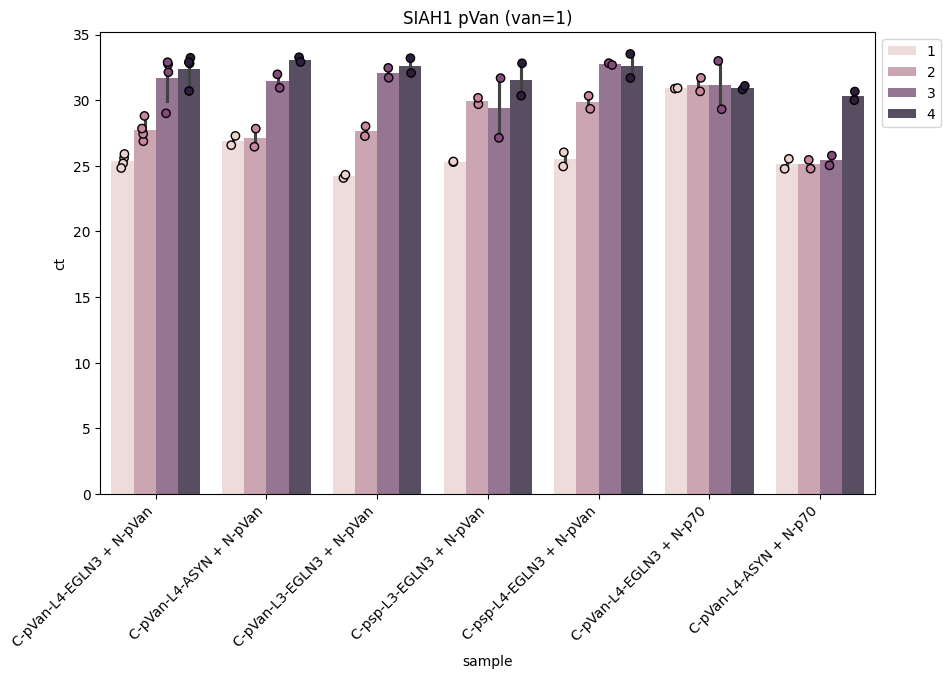

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = bars(df_siah[df_siah['Vanillic acid concentration [µM]'] == 1], x='sample', y='ct', hue='day')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'SIAH1 pVan (van=1)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/3644814049.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


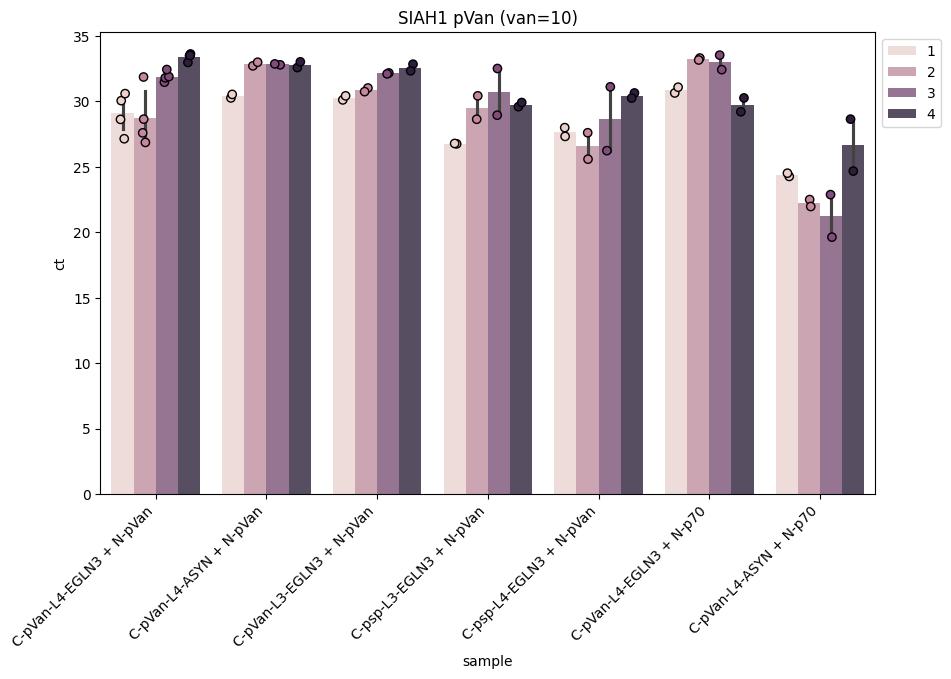

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = bars(df_siah[df_siah['Vanillic acid concentration [µM]'] == 10], x='sample', y='ct', hue='day')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'SIAH1 pVan (van=10)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/3739330327.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


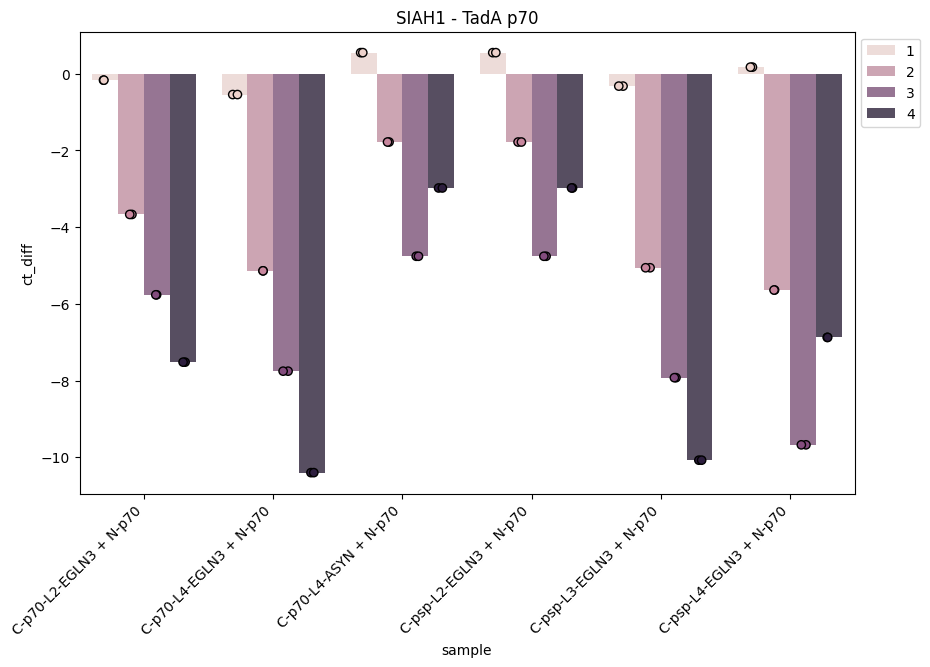

In [27]:
ct_diff = -df_siah.groupby(['plate' , 'day', 'Strain 1', 'Vanillic acid concentration [µM]']).ct.mean() + df_tada.groupby(['plate' , 'day', 'Strain 1', 'Vanillic acid concentration [µM]']).ct.mean()
ct_diff = ct_diff.reset_index().rename(columns={'ct': 'ct_diff'})
ct_diff = pd.merge(ct_diff, meta[meta['Phage'] == 'SIAH1'][['Strain 1', 'Vanillic acid concentration [µM]', 'sample']], on=['Strain 1', 'Vanillic acid concentration [µM]'], how='left')
fig, ax = plt.subplots(figsize=(10, 6))
ax = bars(ct_diff[ct_diff['Vanillic acid concentration [µM]'] == 0], x='sample', y='ct_diff', hue='day')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'SIAH1 - TadA p70')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/3397151252.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


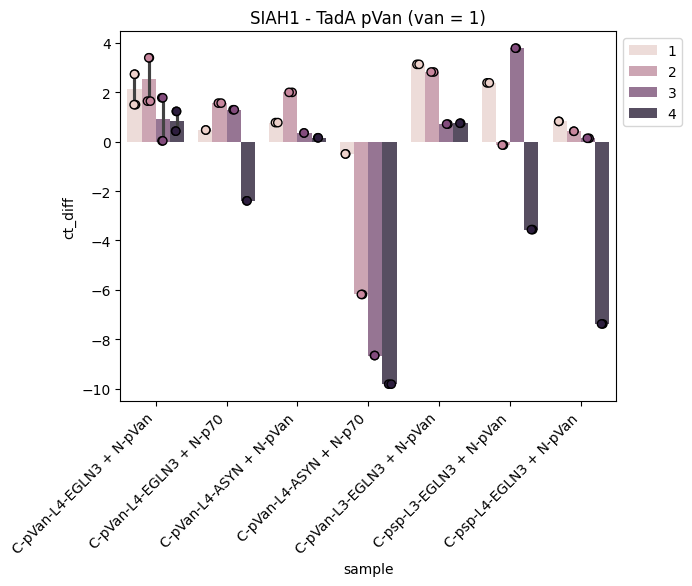

In [28]:
ax = bars(ct_diff[ct_diff['Vanillic acid concentration [µM]'] == 1], x='sample', y='ct_diff', hue='day')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'SIAH1 - TadA pVan (van = 1)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_87991/2906375741.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


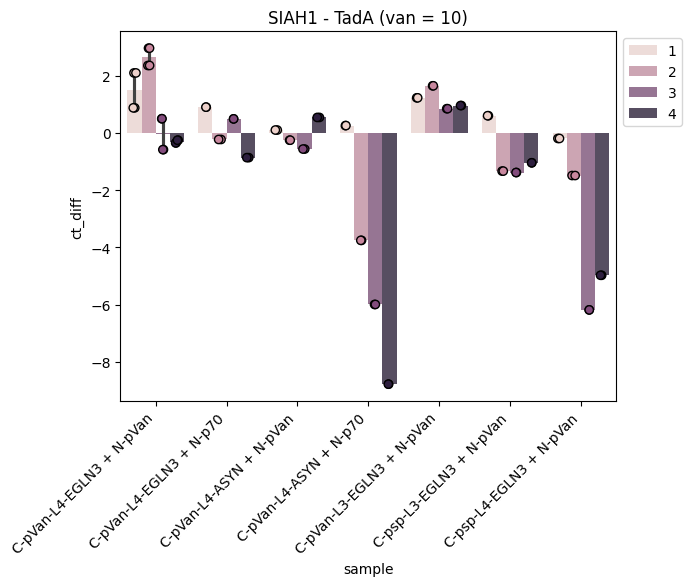

In [29]:
ax = bars(ct_diff[ct_diff['Vanillic acid concentration [µM]'] == 10], x='sample', y='ct_diff', hue='day')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f'SIAH1 - TadA (van = 10)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

Text(0.5, 1.0, 'day3 vs day1')

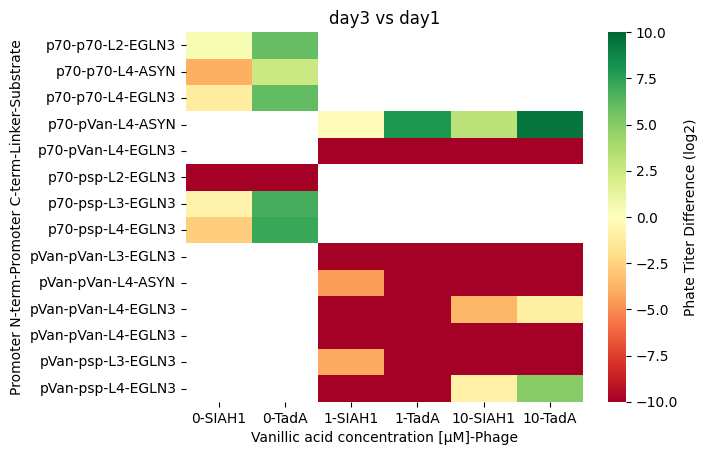

In [35]:
df1 = df[df['day'] == 1].drop(columns=['day']).set_index('well')

df3 = df[df['day'] == 3].drop(columns=['day']).set_index('well')
df3['ct_diff'] = -df3.ct + df1.ct
df3.loc[df3.ct > 32, 'ct_diff'] = -100

df3 = df3.groupby(['Strain 1', 'Linker', 'Substrate', 'Promoter C-term', 'Promoter N-term', 'sample', 'Phage', 'Vanillic acid concentration [µM]']).ct_diff.mean().reset_index()
df3 = df3.pivot(index=['Promoter N-term', 'Promoter C-term', 'Linker', 'Substrate', 'Strain 1', 'sample'], columns=['Vanillic acid concentration [µM]', 'Phage'], values='ct_diff')
df3 = df3.droplevel(['sample', 'Strain 1'])
df3 = df3.sort_index(axis=1)
ax = sns.heatmap(df3, cmap='RdYlGn', center=0, vmin=-10, vmax=10, cbar_kws={'label': 'Phate Titer Difference (log2)'})
ax.set_title('day3 vs day1')

Text(0.5, 1.0, 'day3 vs day1')

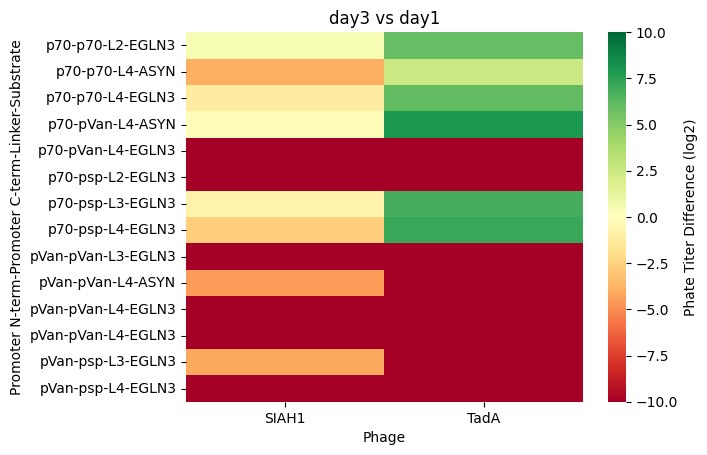

In [40]:
df_novan10 = df[df['Vanillic acid concentration [µM]'] != 10].drop(columns=['Vanillic acid concentration [µM]'])
df1 = df_novan10[df_novan10['day'] == 1].drop(columns=['day']).set_index('well')

df3 = df_novan10[df_novan10['day'] == 3].drop(columns=['day']).set_index('well')

df3['ct_diff'] = -df3.ct + df1.ct
df3.loc[df3.ct > 32, 'ct_diff'] = -100

df3 = df3.groupby(['Strain 1', 'Linker', 'Substrate', 'Promoter C-term', 'Promoter N-term', 'sample', 'Phage']).ct_diff.mean().reset_index()
df3 = df3.pivot(index=['Promoter N-term', 'Promoter C-term', 'Linker', 'Substrate', 'Strain 1', 'sample'], columns=['Phage'], values='ct_diff')
df3 = df3.droplevel(['sample', 'Strain 1'])
df3 = df3.sort_index(axis=1)
ax = sns.heatmap(df3, cmap='RdYlGn', center=0, vmin=-10, vmax=10, cbar_kws={'label': 'Phate Titer Difference (log2)'})
ax.set_title('day3 vs day1')

Text(0.5, 1.0, 'day3 vs day1')

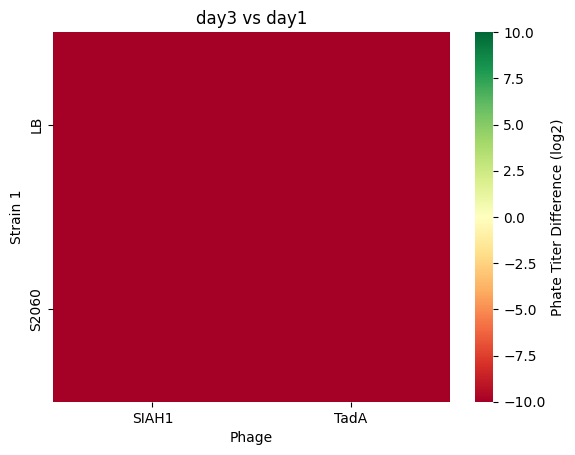

In [48]:
df_novan10 = df[(df['Vanillic acid concentration [µM]'] != 10) & df['Strain 1'].isin({'S2060', 'LB'})]\
    .drop(columns=['Vanillic acid concentration [µM]', 'Promoter N-term', 'Promoter C-term', 'Linker', 'Substrate', 'sample'])
df1 = df_novan10[df_novan10['day'] == 1].drop(columns=['day']).set_index('well')

df3 = df_novan10[df_novan10['day'] == 3].drop(columns=['day']).set_index('well')

df3['ct_diff'] = -df3.ct + df1.ct
df3.loc[df3.ct > 32, 'ct_diff'] = -100

df3 = df3.groupby(['Strain 1', 'Phage']).ct_diff.mean().reset_index()
df3 = df3.pivot(index=['Strain 1'], columns=['Phage'], values='ct_diff')
df3 = df3.sort_index(axis=1)
ax = sns.heatmap(df3, cmap='RdYlGn', center=0, vmin=-10, vmax=10, cbar_kws={'label': 'Phate Titer Difference (log2)'})
ax.set_title('day3 vs day1')

In [45]:
df_novan10

,well,ct,plate,day,Strain 1,Replicate,Linker,Substrate,Promoter C-term,Promoter N-term,Phage,sample
52,E5,30.27,plate1,1,LB,A,NaN,NaN,NaN,NaN,SIAH1,NaN
53,E6,30.12,plate1,1,LB,B,NaN,NaN,NaN,NaN,SIAH1,NaN
58,E11,31.20,plate1,1,LB,A,NaN,NaN,NaN,NaN,TadA,NaN
59,E12,31.23,plate1,1,LB,B,NaN,NaN,NaN,NaN,TadA,NaN
64,F5,24.87,plate1,1,S2060,A,NaN,NaN,NaN,NaN,SIAH1,NaN
65,F6,24.78,plate1,1,S2060,B,NaN,NaN,NaN,NaN,SIAH1,NaN
70,F11,27.59,plate1,1,S2060,A,NaN,NaN,NaN,NaN,TadA,NaN
71,F12,28.05,plate1,1,S2060,B,NaN,NaN,NaN,NaN,TadA,NaN
148,E5,32.87,plate1,2,LB,A,NaN,NaN,NaN,NaN,SIAH1,NaN
149,E6,26.61,plate1,2,LB,B,NaN,NaN,NaN,NaN,SIAH1,NaN


In [41]:
df['Strain 1'].unique()

array(['1084-44-00', '1029-08-00', '1117-44-00', '1033-09-00',
       '1120-44-00', '1035-08-00', '1124-44-00', '1131-44-00', 'LB',
       '1151-44-00', 'S2060', '1084-69-00', '1131-69-00', '1117-69-00',
       '1151-69-00'], dtype=object)

Text(0.5, 1.0, 'day2 vs day1')

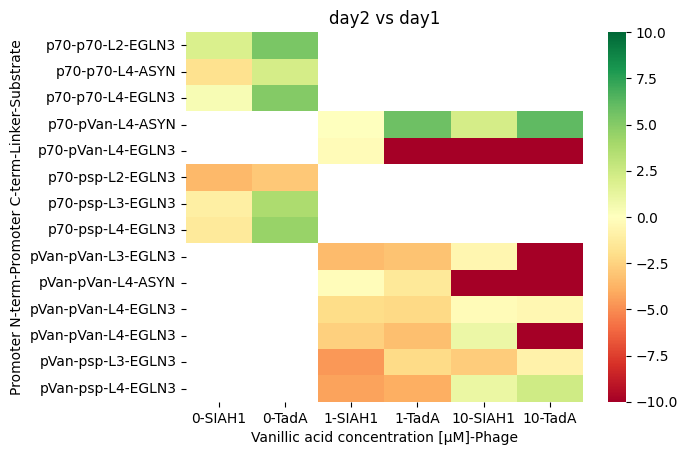

In [31]:
df2 = df[df['day'] == 2].drop(columns=['day']).set_index('well')
df2['ct_diff'] = -df2.ct + df1.ct
df2.loc[df2.ct > 32, 'ct_diff'] = -100

df2 = df2.groupby(['Strain 1', 'Linker', 'Substrate', 'Promoter C-term', 'Promoter N-term', 'sample', 'Phage', 'Vanillic acid concentration [µM]']).ct_diff.mean().reset_index()
df2 = df2.pivot(index=['Promoter N-term', 'Promoter C-term', 'Linker', 'Substrate', 'Strain 1', 'sample'], columns=['Vanillic acid concentration [µM]', 'Phage'], values='ct_diff')
df2 = df2.droplevel(['sample', 'Strain 1'])
df2 = df2.sort_index(axis=1)
ax = sns.heatmap(df2, cmap='RdYlGn', center=0,  vmin=-10, vmax=10)
ax.set_title('day2 vs day1')